# RAPID-MFA 16: Trouble shooting: sudden jumps

# Descriptions

This variant of the stock driven model addresses the _sudden jumps_ issue through spline interpolation, enabling smooth future data projections. It utilizes historical data along with specific target stock values at certain times. Initially, the model demonstrates how to fill future stock data using _linear interpolation_, and how it does not help prevent sudden year-to-year jumps. Then, it shows how implementing _spline interpolation_ effectively resolves this problem. 

We'll use a _cubic spline_ interpolation to estimate the stock values. This method produces smooth curves with continuous derivatives. This is important because _stock changes_ correspond to the 1st derivative of _stocks_ (specifically, the 1st difference). As shown in the figures below, abrupt fluctuations in _stock changes_ caused significant issues, so smoothing these changes is essential. The advantage of _cubic spline_ is that it also ensures smooth derivatives of _stock changes_. 

### Exogenous variables
__Inflows:__ Vehicle data from _Fishman, T., Myers, R. J., Rios, O., & Graedel, T. E. (2018). Implications of emerging vehicle technologies on rare earth supply and demand in the United States. Resources, 7(1), 9._

__Survival curve:__ Weibull distribution, values from _Fishman, T., Myers, R. J., Rios, O., & Graedel, T. E. (2018). Implications of emerging vehicle technologies on rare earth supply and demand in the United States. Resources, 7(1), 9._

### Notes
1. As the linear model is shown just to explain why the spline model is useful, this step can be skipped.
2. This example uses Weibull distribution survival curves, but they can be replaced with any other curves.

### Relations with other RAPID-MFA codes
- `RAPID-MFA-2: The stock driven model`: The modelling steps are following those in this notebook.

### Version, licence, and how to cite

Version 2026.7 - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

This code was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__. 

## 1. Load libraries

In [9]:
import numpy as np
import pandas as pd
import scipy.stats

## 2. Define example input data

In [10]:
# %% 2. Define example input data
input_data = pd.Series([0, 17, 9367, 29639, 65611, 112994, 196655, 405237, 655629, 1002834, 1307203,
                        1584131, 1836332, 2092277, 2537144, 3074043, 3567853, np.nan, np.nan, np.nan,
                        np.nan, np.nan, np.nan, np.nan, 10000000, np.nan, np.nan, np.nan, np.nan, np.nan,
                        np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 50000000, np.nan, np.nan,
                        np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 95000000, np.nan, np.nan,
                        np.nan, np.nan, 105000000], #after 2014, the values are based on milestones for future years
                        name = 'stocks', 
                        index = [1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,
                                2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
                                2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030,
                                2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041,
                                2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050]) #mock values


# Parameters for the survival curve
ages = range(0, len(input_data)) 
shape = 2.428914875
location = 0
scale = 16.93851375

# create the survival curve
survival_curve = scipy.stats.weibull_min.sf(ages, c = shape, loc = location, scale = scale)

## 3. Run the stock-driven model

In [11]:
# %% 3. Run the stock-driven model
units = {'time_interval':   'year', 
         'flows':           'g/year', 
         'stocks':          'g'}

timeframes = cohorts = input_data.index  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.
time_interval = 1
cohort_stop = (cohorts[-1] + time_interval)  # because of exclusive slicing in python, an extra time interval is required

### 3.1. Run the stock-driven model using the linear interpolation

In [12]:
# %%% 3.1. Run the stock-driven model using the linear interpolation
mfa_system_linear = pd.DataFrame(index=timeframes, columns = ['stocks', 
                                                         'inflows', 
                                                         'outflows', 
                                                         'stock_changes'])

mfa_system_linear['stocks'] = input_data

# Fill missing stock values using linear interpolation
mfa_system_linear["stocks"] = mfa_system_linear["stocks"].interpolate(method="linear")

# create survival curves matrix filled with zeros
linear_survival_curves_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# and populate that matrix
for cohort in cohorts:
    # at each iteration, shift the survival curve and fill the next column of the survival curves matrix with the shifted survival curve from the diagonal downwards.
    linear_survival_curves_matrix.loc[cohort: , cohort] = survival_curve[0 : cohort_stop - cohort]
   
# initialize the cohort_survival_matrix filled with zeros
linear_cohorts_survival_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# And populate it
for cohort in cohorts:
    # calculate the inflow of the time-th year
    mfa_system_linear.loc[cohort, 'inflows'] = (
        mfa_system_linear.loc[cohort, 'stocks'] - linear_cohorts_survival_matrix.loc[cohort, : cohort - 1].sum()
    ) / linear_survival_curves_matrix.loc[cohort, cohort]
    # now that the time-th inflow is known, scale the shifted survival curve with this inflow
    linear_cohorts_survival_matrix.loc[:, cohort] = linear_survival_curves_matrix.loc[:, cohort] * mfa_system_linear.loc[cohort, 'inflows']
    
mfa_system_linear["stock_changes"] = np.diff(mfa_system_linear["stocks"], prepend=0)
mfa_system_linear["outflows"] = mfa_system_linear["inflows"] - mfa_system_linear["stock_changes"]

<Axes: ylabel='g/year'>

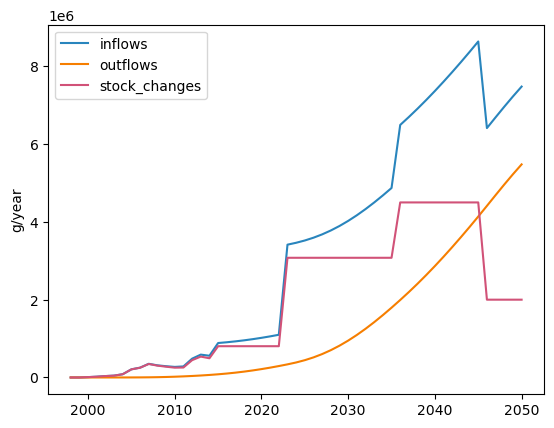

In [13]:
# visualize the MFA system using the linear interpolation
mfa_system_linear[['inflows', 'outflows', 'stock_changes']].plot(ylabel=units['flows'], 
                                                                        color=["#2985BD", "#F67E00", "#D15278"])

### 3.2. Run the stock-driven model using the spline interpolation

In [14]:
# %%% 3.2. Run the stock-driven model using the spline interpolation
mfa_system_spline = pd.DataFrame(index=timeframes, columns = ['stocks', 
                                                         'inflows', 
                                                         'outflows', 
                                                         'stock_changes'])

mfa_system_spline['stocks'] = input_data

# Fill missing stock values using cubic spline interpolation
mfa_system_spline["stocks"] = mfa_system_spline["stocks"].interpolate(method="cubicspline")

# create survival curves matrix filled with zeros
spline_survival_curves_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# and populate that matrix
for cohort in cohorts:
    # at each iteration, shift the survival curve and fill the next column of the survival curves matrix with the shifted survival curve from the diagonal downwards.
    spline_survival_curves_matrix.loc[cohort: , cohort] = survival_curve[0 : cohort_stop - cohort]
   
# initialize the cohort_survival_matrix filled with zeros
spline_cohorts_survival_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# And populate it
for cohort in cohorts:
    # calculate the inflow of the time-th year
    mfa_system_spline.loc[cohort, 'inflows'] = (
        mfa_system_spline.loc[cohort, 'stocks'] - spline_cohorts_survival_matrix.loc[cohort, : cohort - 1].sum()
    ) / spline_survival_curves_matrix.loc[cohort, cohort]
    # now that the time-th inflow is known, scale the shifted survival curve with this inflow
    spline_cohorts_survival_matrix.loc[:, cohort] = spline_survival_curves_matrix.loc[:, cohort] * mfa_system_spline.loc[cohort, 'inflows']

mfa_system_spline["stock_changes"] = np.diff(mfa_system_spline["stocks"], prepend=0)
mfa_system_spline["outflows"] = mfa_system_spline["inflows"] - mfa_system_spline["stock_changes"]

<Axes: ylabel='g/year'>

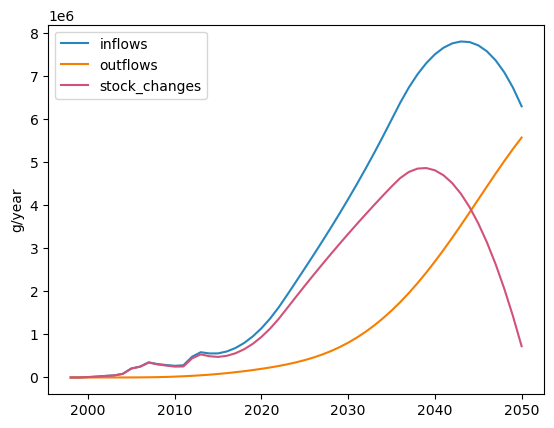

In [15]:
# visualize the MFA system using the spline interpolation
mfa_system_spline[['inflows', 'outflows', 'stock_changes']].plot(ylabel=units['flows'], 
                                                                        color=["#2985BD", "#F67E00", "#D15278"])